# LightGBM Challenger Model

**Purpose**: Train a LightGBM gradient boosting classifier as a challenger to the WoE + Logistic
Regression champion model. Uses raw (non-WoE) features so the tree model can exploit non-linear
relationships and interactions that the linear champion cannot.

**Why raw features, not WoE?**  
WoE transformation discretises continuous variables into a handful of bins and maps each bin to a
single log-odds value. This is precisely what logistic regression needs to handle non-linearity —
but LightGBM finds optimal split points on its own. Applying WoE first would destroy the
fine-grained information the tree would otherwise exploit, making the challenger artificially
weaker and the comparison less meaningful.

**Evaluation metric**: F1 score (primary), AUC-ROC (secondary).  
**Two split strategies** — set `SPLIT_STRATEGY` below:
- `"out_of_time"` — 2021 held out as test; validation carved from last training year (2020)
- `"out_of_sample"` — random 20% of companies held out; validation carved from remaining train companies

**Tuning modes** — set `TUNING_MODE` below:
- `"quick"` — 30 Optuna trials, 5 000 SHAP samples (~15-20 min on M2)
- `"thorough"` — 200 Optuna trials, 20 000 SHAP samples (~2 h on M2, suitable for overnight)

## 0. Imports & Configuration

In [ ]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

# ╔══════════════════════════════════════════════════════════════╗
# ║  PRIMARY CONFIGURATION — edit these two lines              ║
# ╚══════════════════════════════════════════════════════════════╝
SPLIT_STRATEGY: str = "out_of_time"   # "out_of_time" | "out_of_sample"
TUNING_MODE: str = "quick"          # "quick"       | "thorough"

RANDOM_STATE = 42
TARGET_COL = "default"
ID_COL = "ID"
DATE_COL = "obs_date"

DATA_ROOT = Path("data")
PROCESSING_DIR = DATA_ROOT / "processing"
LOG_DIR = DATA_ROOT / "logs"
RESULTS_DIR = Path("results") / "LightGBM"   # outputs written here

SPLIT_FILE_MAP = {
    "out_of_time":   PROCESSING_DIR / "data_split_out_of_time_last_year_train_test.csv",
    "out_of_sample": PROCESSING_DIR / "data_split_out_of_sample_train_test.csv",
}

TUNING_CONFIG = {
    "quick": {"n_trials": 30, "n_estimators_ceiling": 800, "shap_samples": 5_000, "timeout_s": 600},
    "thorough": {"n_trials": 200, "n_estimators_ceiling": 2000, "shap_samples": 20_000, "timeout_s": 7200},
}

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10})

if SPLIT_STRATEGY not in SPLIT_FILE_MAP:
    raise ValueError(f"SPLIT_STRATEGY must be one of {list(SPLIT_FILE_MAP)}, got {SPLIT_STRATEGY!r}")
if TUNING_MODE not in TUNING_CONFIG:
    raise ValueError(f"TUNING_MODE must be one of {list(TUNING_CONFIG)}, got {TUNING_MODE!r}")

active_cfg = TUNING_CONFIG[TUNING_MODE]
print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Tuning mode: {TUNING_MODE} ({active_cfg['n_trials']} trials, "
      f"timeout {active_cfg['timeout_s']}s)")
print(f"Results dir: {RESULTS_DIR.resolve()}")

/Users/azernaczuk/Documents/0sobiste/github/ING_hubs_predict_default/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Split strategy : out_of_time
Tuning mode    : quick (30 trials, timeout 600s)
Results dir    : /Users/azernaczuk/Documents/0sobiste/github/ING_hubs_predict_default/results/LightGBM


## 1. Load Data & Assign Splits

In [2]:
def load_panel_with_split(
    features_path: Path,
    split_path: Path,
    id_col: str,
    date_col: str,
) -> pd.DataFrame:
    """Load the cleaned panel and attach train/test split labels.

    Parameters
    ----------
    features_path : Path
        Cleaned, imputed panel dataset (semicolon-delimited).
    split_path : Path
        Split assignment file with columns (ID, obs_date, split).
    id_col, date_col : str
        Key column names used for merging.

    Returns
    -------
    pd.DataFrame
        Panel with an additional 'split' column ('train' or 'test').
    """
    panel = pd.read_csv(features_path, sep=";", low_memory=False)
    splits = pd.read_csv(split_path, sep=";")[[id_col, date_col, "split"]]

    panel[date_col] = pd.to_datetime(panel[date_col], errors="coerce")
    splits[date_col] = pd.to_datetime(splits[date_col], errors="coerce")

    merged = panel.merge(splits, on=[id_col, date_col], how="inner", validate="one_to_one")

    unmatched = len(panel) - len(merged)
    if unmatched > 0:
        raise ValueError(
            f"{unmatched} rows from the panel could not be matched to a split assignment. "
            "Ensure both files were produced by the same run of data_processing.ipynb."
        )
    return merged


panel_df = load_panel_with_split(
    PROCESSING_DIR / "cleaned_panel_imputed.csv",
    SPLIT_FILE_MAP[SPLIT_STRATEGY],
    ID_COL,
    DATE_COL,
)

print(f"Panel shape: {panel_df.shape}")
print(f"Date range: {panel_df[DATE_COL].min().date()} → {panel_df[DATE_COL].max().date()}")
print(f"\nSplit counts:\n{panel_df['split'].value_counts()}")
print("\nDefault rate by split:")
print(panel_df.groupby('split')[TARGET_COL].mean().round(4).to_string())

Panel shape: (125758, 79)
Date range: 2015-01-01 → 2021-12-31

Split counts:
split
train    119128
test       6630
Name: count, dtype: int64

Default rate by split:
split
test     0.0481
train    0.0708


In [ ]:
# Identify feature columns — all numeric columns except metadata and target.
METADATA_COLS = {ID_COL, DATE_COL, TARGET_COL, "split"}
feature_columns: list[str] = [
    c for c in panel_df.select_dtypes(include=[np.number]).columns
    if c not in METADATA_COLS
]

n_original   = sum(1 for c in feature_columns if not c.endswith("_missing_flag"))
n_flag       = sum(1 for c in feature_columns if c.endswith("_missing_flag"))

print(f"Total LightGBM features: {len(feature_columns)}")
print(f"  Original variables: {n_original}")
print(f"  Missing-value flags: {n_flag}")

Total LightGBM features : 75
  Original variables    : 39
  Missing-value flags   : 36


## 2. Carve Validation Set from Train

Both split files provide only `train` / `test` labels. LightGBM requires a held-out validation set
for early stopping. We carve it from the training portion in a way that is *consistent with the
split philosophy*:

- **Out-of-time**: hold out the last calendar year of the training window (2020) as validation.
  Train on 2015-2019, validate on 2020, test on 2021.  
  *Rationale*: simulates the real deployment cycle where the model is re-trained each year and
  validated on the most recent year before going live.

- **Out-of-sample**: reserve a random 20 % of the training *companies* (stratified by whether the
  company ever defaulted) as validation. No company appears in more than one of train/valid/test.  
  *Rationale*: preserves the OOS philosophy — every split tests generalisation to entirely
  unseen entities.

In [ ]:
def carve_validation_out_of_time(
    panel: pd.DataFrame,
    date_col: str,
) -> pd.DataFrame:
    """Hold out the last calendar year of the train partition as validation.

    Parameters
    ----------
    panel : pd.DataFrame
        Panel restricted to the train split, with a parsed date column.
    date_col : str
        Name of the observation date column.

    Returns
    -------
    pd.DataFrame
        Same frame with 'split' updated to 'train' / 'validation'.
    """
    last_year = int(panel[date_col].dt.year.max())
    panel = panel.copy()
    panel["split"] = np.where(panel[date_col].dt.year == last_year, "validation", "train")
    return panel


def carve_validation_out_of_sample(
    panel: pd.DataFrame,
    id_col: str,
    target_col: str,
    val_fraction: float = 0.20,
    random_state: int = 42,
) -> pd.DataFrame:
    """Reserve a company-stratified random subset of train companies as validation.

    Stratification is by whether the company ever defaulted, so the validation
    default rate mirrors that of the full training pool.

    Parameters
    ----------
    panel : pd.DataFrame
        Panel restricted to the train split.
    id_col : str
        Company identifier column.
    target_col : str
        Binary default indicator.
    val_fraction : float
        Fraction of train *companies* to move into validation.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Same frame with 'split' updated to 'train' / 'validation'.
    """
    company_profile = (
        panel.groupby(id_col)[target_col]
        .max()
        .rename("ever_defaulted")
        .reset_index()
    )

    rng = np.random.default_rng(random_state)
    val_company_ids: list = []
    for _, group in company_profile.groupby("ever_defaulted"):
        n_val = max(1, int(len(group) * val_fraction))
        chosen = rng.choice(group[id_col].to_numpy(), size=n_val, replace=False)
        val_company_ids.extend(chosen.tolist())

    panel = panel.copy()
    panel["split"] = np.where(panel[id_col].isin(val_company_ids), "validation", "train")
    return panel


train_raw = panel_df[panel_df["split"] == "train"].copy()
test_raw  = panel_df[panel_df["split"] == "test"].copy()

if SPLIT_STRATEGY == "out_of_time":
    train_with_val = carve_validation_out_of_time(train_raw, DATE_COL)
else:
    train_with_val = carve_validation_out_of_sample(train_raw, ID_COL, TARGET_COL)

model_train = train_with_val[train_with_val["split"] == "train"]
model_valid = train_with_val[train_with_val["split"] == "validation"]

if len(model_valid) == 0:
    raise ValueError(
        f"Validation set is empty after carving ({SPLIT_STRATEGY}). "
        "Check date coverage or company count in the training split."
    )

X_train = model_train[feature_columns].reset_index(drop=True)
y_train = model_train[TARGET_COL].reset_index(drop=True)
X_valid = model_valid[feature_columns].reset_index(drop=True)
y_valid = model_valid[TARGET_COL].reset_index(drop=True)
X_test = test_raw[feature_columns].reset_index(drop=True)
y_test = test_raw[TARGET_COL].reset_index(drop=True)

# Sanity-check: the imputation pipeline should have removed all NaN values.
n_nan_train = int(X_train.isna().sum().sum())
n_nan_valid = int(X_valid.isna().sum().sum())
n_nan_test = int(X_test.isna().sum().sum())
if n_nan_train > 0 or n_nan_valid > 0 or n_nan_test > 0:
    raise ValueError(
        f"Unexpected NaN values — train: {n_nan_train}, valid: {n_nan_valid}, "
        f"test: {n_nan_test}. Re-check imputation in data_processing.ipynb."
    )
print("NaN check passed: no missing values in any feature matrix.")

imbalance_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f"\nTrain: {len(X_train):>7,} rows | default rate: {y_train.mean():.4f}")
print(f"Validation: {len(X_valid):>7,} rows | default rate: {y_valid.mean():.4f}")
print(f"Test: {len(X_test):>7,} rows | default rate: {y_test.mean():.4f}")
print(f"Neg/pos ratio (train): {imbalance_ratio:.1f}:1")

# Verify no ID leaks between model_train and model_valid (both conditions apply).
if SPLIT_STRATEGY == "out_of_sample":
    id_train_val = set(model_train[ID_COL])
    id_valid_set = set(model_valid[ID_COL])
    id_test_set  = set(test_raw[ID_COL])
    overlap_tv = id_train_val & id_valid_set
    overlap_vt = id_valid_set & id_test_set
    assert not overlap_tv, f"ID leak train↔valid: {len(overlap_tv)} companies"
    assert not overlap_vt, f"ID leak valid↔test: {len(overlap_vt)} companies"
    print("ID overlap checks passed: no company appears in more than one partition.")

if SPLIT_STRATEGY == "out_of_time":
    train_years = sorted(model_train[DATE_COL].dt.year.unique())
    valid_years = sorted(model_valid[DATE_COL].dt.year.unique())
    test_years  = sorted(test_raw[DATE_COL].dt.year.unique())
    print(f"\nTrain years: {train_years}")
    print(f"Valid years: {valid_years}")
    print(f"Test years : {test_years}")

NaN check passed: no missing values in any feature matrix.

Train      : 104,288 rows | default rate: 0.0750
Validation :  14,840 rows | default rate: 0.0407
Test       :   6,630 rows | default rate: 0.0481
Neg/pos ratio (train): 12.3:1

Train years : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019)]
Valid years : [np.int32(2020)]
Test years  : [np.int32(2021)]


## 3. Baseline LightGBM

In [5]:
def train_lightgbm(
    X_fit: pd.DataFrame,
    y_fit: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    params: dict,
    early_stopping_rounds: int = 50,
) -> lgb.LGBMClassifier:
    """Fit a LightGBM classifier with early stopping on the validation set.

    Parameters
    ----------
    X_fit, y_fit : training features and target.
    X_val, y_val : validation features and target for early stopping.
    params : dict
        LGBMClassifier keyword arguments (excluding is_unbalance, random_state,
        verbosity, n_jobs which are always set here).
    early_stopping_rounds : int
        Stop if validation loss does not improve for this many rounds.

    Returns
    -------
    lgb.LGBMClassifier
        Fitted model.
    """
    fixed = {
        "is_unbalance": True,   # auto-weights minority class; cleaner than scale_pos_weight
        "random_state": RANDOM_STATE,
        "verbosity": -1,
        "n_jobs": -1,
    }
    model = lgb.LGBMClassifier(**{**params, **fixed})
    model.fit(
        X_fit, y_fit,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    return model


baseline_params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "num_leaves": 31,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

baseline_model = train_lightgbm(X_train, y_train, X_valid, y_valid, baseline_params)
print(f"Best iteration (early stopping): {baseline_model.best_iteration_}")
print(f"Validation AUC: {roc_auc_score(y_valid, baseline_model.predict_proba(X_valid)[:, 1]):.4f}")

Best iteration (early stopping): 14
Validation AUC: 0.9711


## 4. Hyperparameter Tuning with Optuna

Optimise for **F1 score at the optimal threshold** on the validation set.  
`num_leaves` is bounded to `2^max_depth - 1` to avoid the LightGBM internal cap silently
wasting trial budget.

In [ ]:
def find_optimal_f1_threshold(y_true: pd.Series, probabilities: np.ndarray) -> float:
    """Return the probability threshold that maximises F1 on the provided labels.

    Parameters
    ----------
    y_true : pd.Series
        Ground-truth binary labels.
    probabilities : np.ndarray
        Predicted probabilities for the positive class.

    Returns
    -------
    float
        Threshold in [0.01, 0.99] that maximises F1.
    """
    thresholds = np.arange(0.01, 1.0, 0.01)
    f1_scores = [
        f1_score(y_true, (probabilities >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    return float(thresholds[int(np.argmax(f1_scores))])


def optuna_objective(trial: optuna.Trial) -> float:
    """Optuna objective: return validation F1 at the optimal threshold.

    num_leaves is bounded to [min(15, max_leaves), max_leaves] where
    max_leaves = min(63, 2^max_depth - 1).  Both the lower *and* upper bounds
    are clamped so that the constraint low <= high always holds — e.g. for
    max_depth=3, max_leaves=7, so num_leaves is fixed at 7.

    Parameters
    ----------
    trial : optuna.Trial

    Returns
    -------
    float
        Validation F1 score.
    """
    max_depth  = trial.suggest_int("max_depth", 3, 8)
    max_leaves = min(63, 2**max_depth - 1)   # theoretical ceiling for this depth
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, active_cfg["n_estimators_ceiling"], step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", min(15, max_leaves), max_leaves),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = train_lightgbm(X_train, y_train, X_valid, y_valid, params,
                           early_stopping_rounds=30)
    valid_probas = model.predict_proba(X_valid)[:, 1]
    threshold = find_optimal_f1_threshold(y_valid, valid_probas)
    best_f1 = f1_score(y_valid, (valid_probas >= threshold).astype(int))

    trial.set_user_attr("best_threshold", threshold)
    trial.set_user_attr("best_iteration", model.best_iteration_)
    return best_f1


study = optuna.create_study(
    direction="maximize",
    study_name=f"lgb_f1_{SPLIT_STRATEGY}",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(
    optuna_objective,
    n_trials=active_cfg["n_trials"],
    timeout=active_cfg["timeout_s"],
    show_progress_bar=True,
)

print(f"\nTrials completed: {len(study.trials)}")
print(f"Best validation F1: {study.best_value:.4f}")
print(f"Best threshold: {study.best_trial.user_attrs['best_threshold']:.2f}")
print("Best params:")
for param_name, param_value in study.best_params.items():
    print(f"  {param_name}: {param_value}")

Best trial: 12. Best value: 0.654321: 100%|██████████| 30/30 [00:23<00:00,  1.27it/s, 23.70/600 seconds]


Trials completed  : 30
Best validation F1: 0.6543
Best threshold    : 0.48
Best params:
  max_depth: 7
  n_estimators: 400
  learning_rate: 0.03462032368781169
  num_leaves: 50
  min_child_samples: 22
  subsample: 0.9684109785465758
  colsample_bytree: 0.865547742098366
  reg_alpha: 0.015372236942180512
  reg_lambda: 0.027866855152676073


In [7]:
# Retrain with the best params found by Optuna.
# Early stopping is re-applied so the exact number of trees is data-driven.
tuned_model = train_lightgbm(
    X_train, y_train, X_valid, y_valid,
    params=study.best_params,
    early_stopping_rounds=50,
)
print(f"Final model — best iteration: {tuned_model.best_iteration_}")

Final model — best iteration: 23


## 5. Threshold Optimisation on Validation Set

The threshold is selected to maximise F1 on the **validation set only**.  
It is then applied unchanged to the test set to obtain an unbiased estimate.

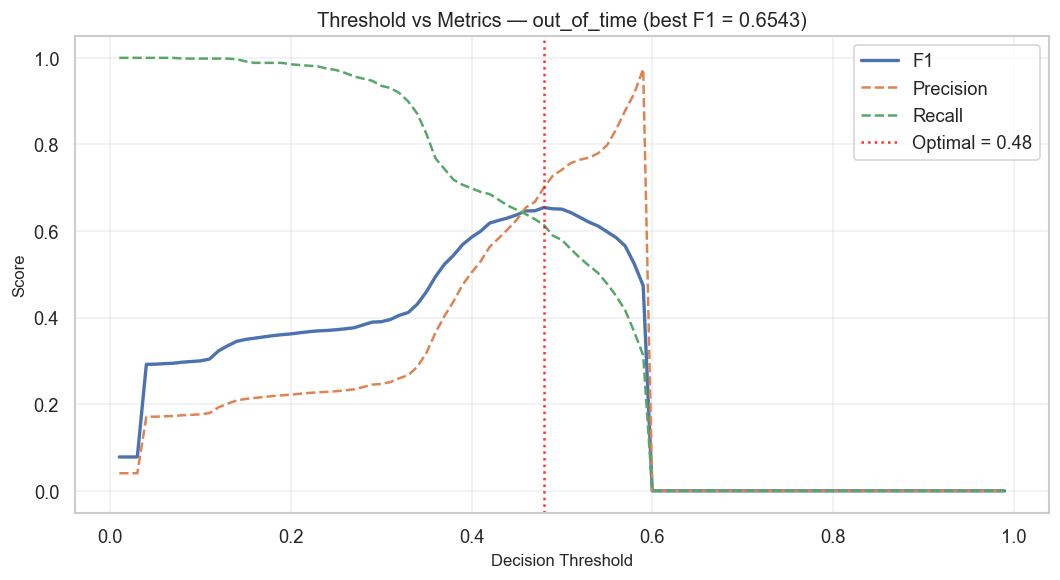


--- Validation (threshold=0.48) ---
     auc_roc: 0.9707
          f1: 0.6543
   precision: 0.7000
      recall: 0.6142
   threshold: 0.4800

--- Train (threshold=0.48) ---
     auc_roc: 0.9780
          f1: 0.7375
   precision: 0.7307
      recall: 0.7446
   threshold: 0.4800

Overfit check — F1 gap (train − validation): 0.0832
  ⚠  Gap > 0.05: consider stronger regularisation (higher reg_alpha/lambda, lower max_depth, higher min_child_samples).


In [ ]:
def evaluate_at_threshold(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    label: str = "Set",
) -> dict[str, float]:
    """Compute classification metrics at a fixed probability threshold.

    Parameters
    ----------
    y_true : pd.Series
        True binary labels.
    probabilities : np.ndarray
        Predicted probabilities for the positive class.
    threshold : float
        Decision boundary.
    label : str
        Display name used in print output.

    Returns
    -------
    dict[str, float]
        Metric name → value.
    """
    predictions = (probabilities >= threshold).astype(int)
    metrics = {
        "auc_roc": float(roc_auc_score(y_true, probabilities)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions)),
        "threshold": threshold,
    }
    print(f"\n--- {label} (threshold={threshold:.2f}) ---")
    for name, val in metrics.items():
        print(f"  {name:>10s}: {val:.4f}")
    return metrics


def plot_threshold_sweep(
    y_true: pd.Series,
    probabilities: np.ndarray,
    optimal_threshold: float,
) -> None:
    """Plot F1, Precision, and Recall across all thresholds with the optimal marked.

    Parameters
    ----------
    y_true : pd.Series
        True labels.
    probabilities : np.ndarray
        Predicted probabilities.
    optimal_threshold : float
        Threshold to highlight.
    """
    thresholds = np.arange(0.01, 1.0, 0.01)
    f1_vals, prec_vals, rec_vals = [], [], []
    for t in thresholds:
        preds = (probabilities >= t).astype(int)
        f1_vals.append(f1_score(y_true, preds, zero_division=0))
        prec_vals.append(precision_score(y_true, preds, zero_division=0))
        rec_vals.append(recall_score(y_true, preds))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, f1_vals, label="F1", linewidth=2)
    ax.plot(thresholds, prec_vals, label="Precision", linestyle="--")
    ax.plot(thresholds, rec_vals, label="Recall", linestyle="--")
    ax.axvline(optimal_threshold, color="red", linestyle=":", alpha=0.8, label=f"Optimal = {optimal_threshold:.2f}")
    best_f1 = f1_vals[int(np.argmax(f1_vals))]
    ax.set_title(f"Threshold vs Metrics — {SPLIT_STRATEGY} (best F1 = {best_f1:.4f})")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


valid_probas = tuned_model.predict_proba(X_valid)[:, 1]
optimal_threshold = find_optimal_f1_threshold(y_valid, valid_probas)

plot_threshold_sweep(y_valid, valid_probas, optimal_threshold)

valid_metrics = evaluate_at_threshold(y_valid, valid_probas, optimal_threshold, "Validation")
train_metrics = evaluate_at_threshold(
    y_train, tuned_model.predict_proba(X_train)[:, 1], optimal_threshold, "Train"
)

f1_gap = train_metrics["f1"] - valid_metrics["f1"]
print(f"\nOverfit check — F1 gap (train − validation): {f1_gap:.4f}")
if f1_gap > 0.05:
    print("Gap > 0.05: consider stronger regularisation (higher reg_alpha/lambda, "
          "lower max_depth, higher min_child_samples)!")
else:
    print("No significant overfitting.")

## 6. SHAP Interpretability

SHAP values decompose each prediction into per-feature contributions, providing local (individual
loan) and global (portfolio-level) explanations. `TreeExplainer` is exact for tree ensembles —
no approximation is required and it is the fastest option.

SHAP values here are in **log-odds space** (the model's raw output). The *sign* directly
indicates direction of risk: positive SHAP contribution → higher default probability.

In [ ]:
def load_feature_name_map(
    iv_summary_path: Path,
    feature_columns: list[str],
) -> dict[str, str]:
    """Build a mapping from technical feature names to human-readable descriptions.

    Falls back to the technical name when no description is available or when
    the IV summary file is absent / does not contain a name column.

    Parameters
    ----------
    iv_summary_path : Path
        Path to woe_iv_summary.csv produced by feature_engineering.ipynb.
    feature_columns : list[str]
        All feature columns used by LightGBM.

    Returns
    -------
    dict[str, str]
        Technical name → readable description.
    """
    name_map: dict[str, str] = {}
    if iv_summary_path.exists():
        iv_df = pd.read_csv(iv_summary_path)
        # Column may be 'feature_name', 'name', or absent — be defensive.
        name_col = next(
            (c for c in ("feature_name", "name", "description") if c in iv_df.columns),
            None,
        )
        if name_col is not None and "feature" in iv_df.columns:
            name_map = dict(zip(iv_df["feature"], iv_df[name_col]))
        else:
            print(
                "IV summary found but no name column detected! "
                f"(columns: {list(iv_df.columns)}). Using technical names."
            )
    else:
        print(f"IV summary not found at {iv_summary_path}! Using technical names.")

    for col in feature_columns:
        if col not in name_map:
            if col.endswith("_missing_flag"):
                base = col[: -len("_missing_flag")]
                name_map[col] = f"{name_map.get(base, base)} (missing)"
            else:
                name_map[col] = col
    return name_map


def compute_shap_values(
    model: lgb.LGBMClassifier,
    X: pd.DataFrame,
    max_samples: int,
    random_state: int = 42,
) -> tuple[shap.Explanation, pd.DataFrame]:
    """Compute SHAP values via TreeExplainer, subsampling if needed.

    The returned DataFrame preserves the *original positional index* of X so
    that callers can align labels via ``y.iloc[X_sample.index]``.

    Parameters
    ----------
    model : lgb.LGBMClassifier
        Fitted LightGBM model.
    X : pd.DataFrame
        Feature matrix to explain. Must have a RangeIndex (reset before calling).
    max_samples : int
        Maximum rows to pass to SHAP (trade-off speed vs. precision).
    random_state : int
        Seed for subsampling.

    Returns
    -------
    tuple[shap.Explanation, pd.DataFrame]
        SHAP Explanation object and the (possibly subsampled) feature matrix.
        The DataFrame index matches the corresponding rows in X so that
        ``y.iloc[returned_df.index]`` gives correctly aligned labels.
    """
    if len(X) > max_samples:
        # Do NOT reset_index — preserve original positions for y alignment.
        X_sample = X.sample(n=max_samples, random_state=random_state)
        print(f"Subsampled for SHAP: {len(X):,} → {max_samples:,} rows.")
    else:
        X_sample = X.copy()

    explainer = shap.TreeExplainer(model)
    explanation = explainer(X_sample)
    return explanation, X_sample


feature_name_map = load_feature_name_map(LOG_DIR / "woe_iv_summary.csv", feature_columns)

shap_explanation, X_shap_sample = compute_shap_values(
    tuned_model, X_valid,
    max_samples=active_cfg["shap_samples"],
)
print(f"SHAP array shape: {shap_explanation.values.shape}")

Subsampled for SHAP: 14,840 → 5,000 rows.
SHAP array shape: (5000, 75)


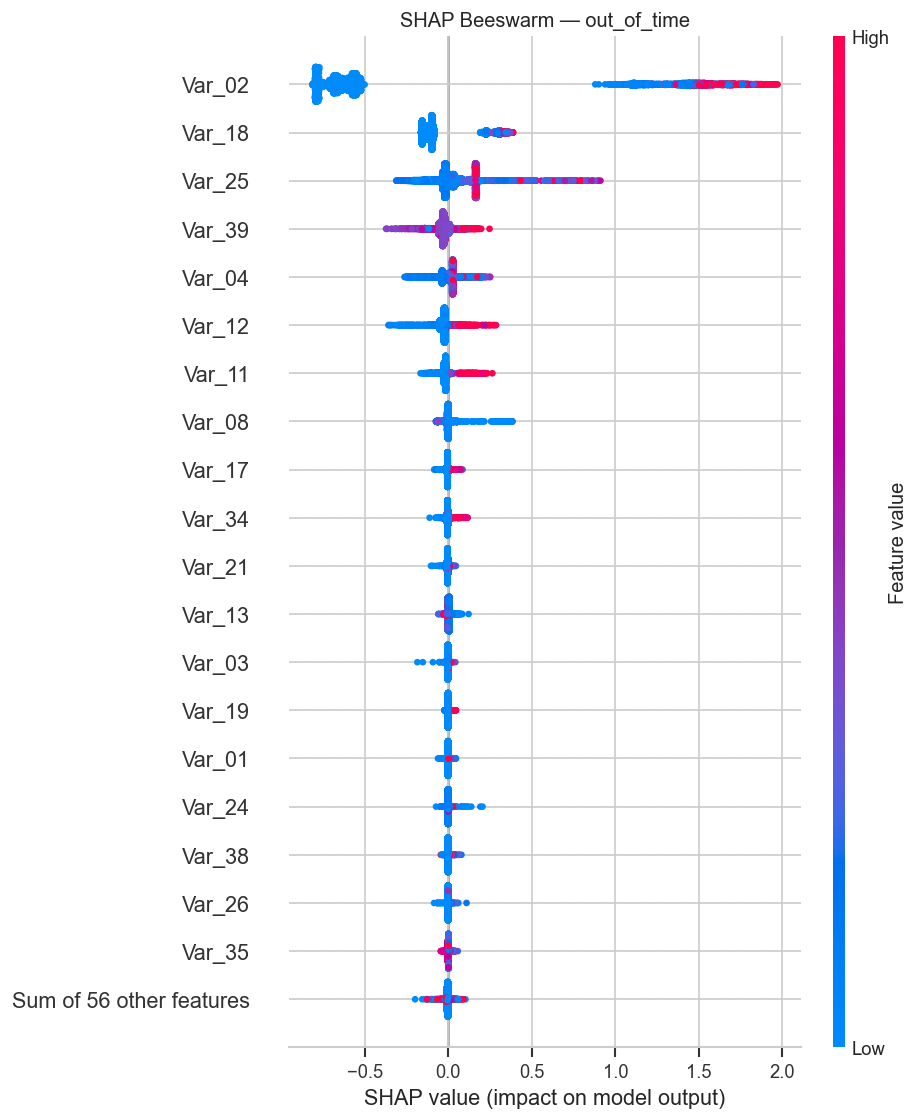

In [10]:
# SHAP beeswarm — global importance with direction of effect.
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title(f"SHAP Beeswarm — {SPLIT_STRATEGY}")
plt.tight_layout()
plt.show()

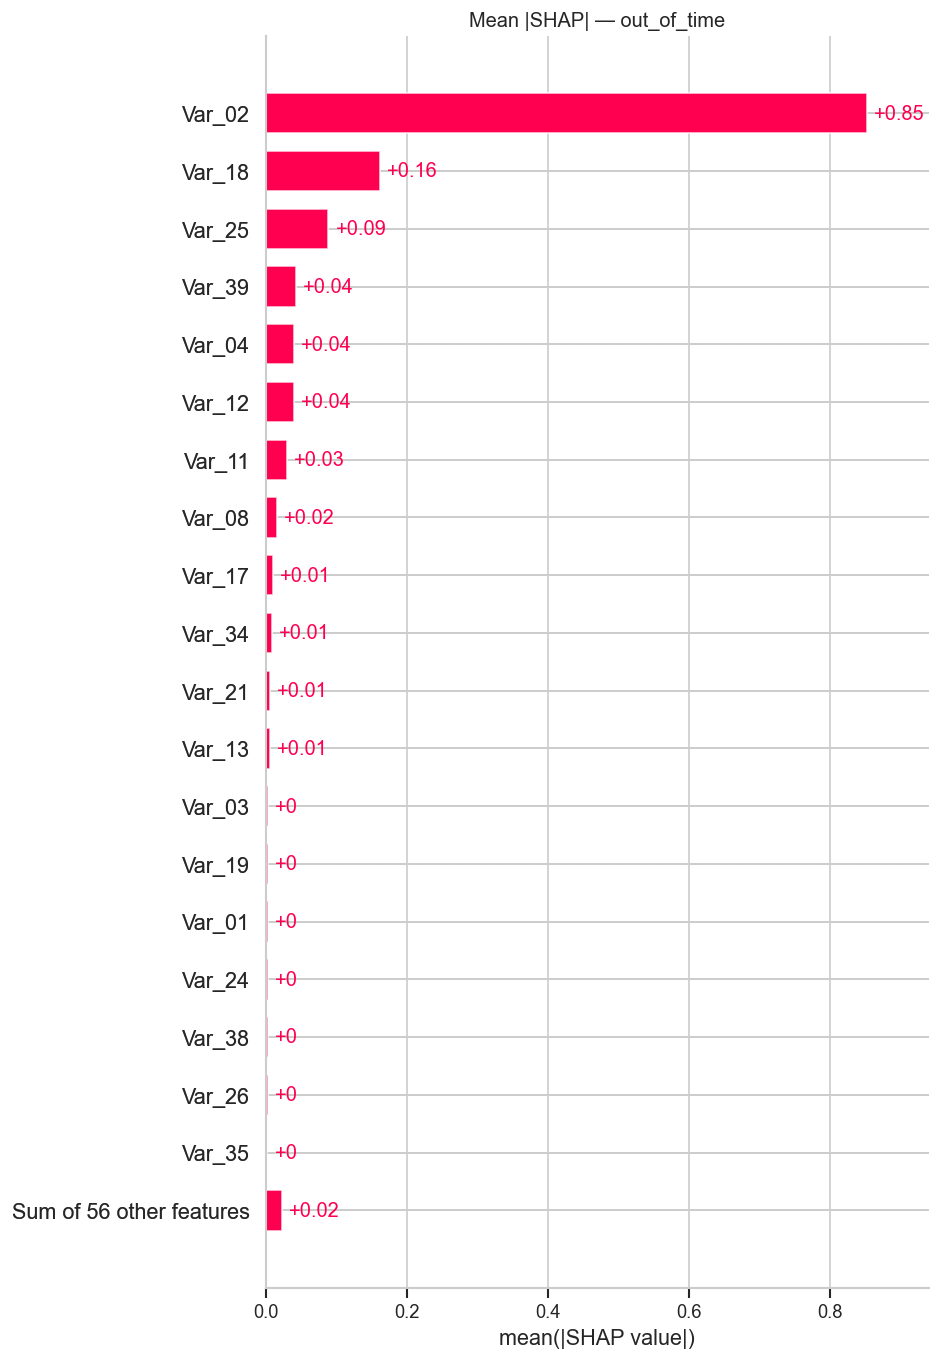

In [11]:
# SHAP bar — mean |SHAP| per feature (global importance).
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title(f"Mean |SHAP| — {SPLIT_STRATEGY}")
plt.tight_layout()
plt.show()

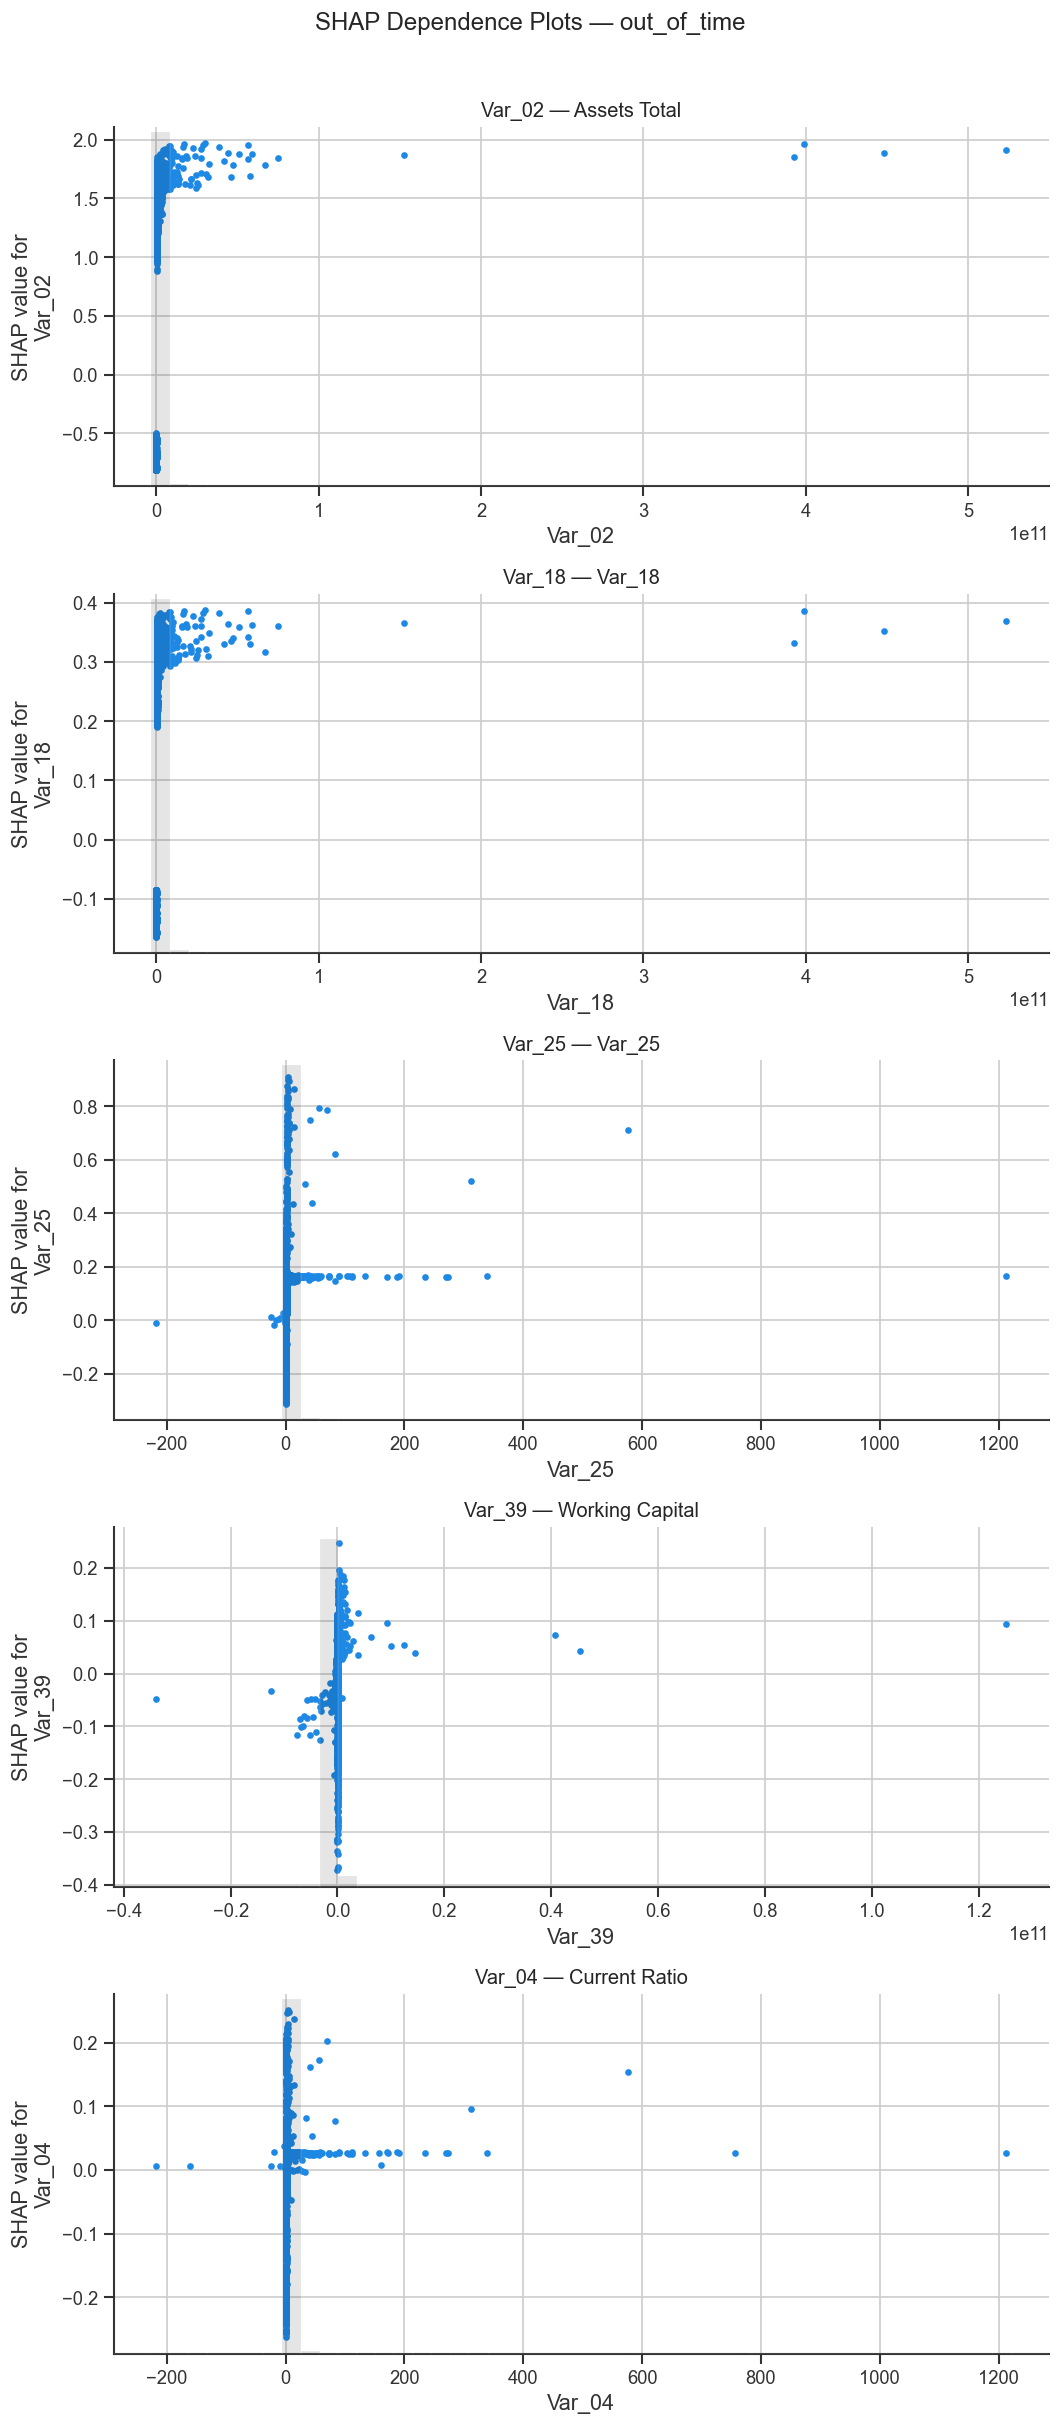

In [12]:
def plot_shap_dependence_top_n(
    shap_explanation: shap.Explanation,
    feature_name_map: dict[str, str],
    n_features: int = 5,
) -> None:
    """Scatter plot of SHAP value vs. raw feature value for the top N features.

    Reveals non-linear relationships and threshold effects that the logistic
    regression champion cannot capture.

    Parameters
    ----------
    shap_explanation : shap.Explanation
        SHAP explanation object.
    feature_name_map : dict[str, str]
        Technical → readable name mapping.
    n_features : int
        Number of top features to plot.
    """
    mean_abs_shap = np.abs(shap_explanation.values).mean(axis=0)
    n_features = min(n_features, len(shap_explanation.feature_names))
    top_indices = np.argsort(mean_abs_shap)[::-1][:n_features]
    top_feature_names = [shap_explanation.feature_names[i] for i in top_indices]

    fig, axes = plt.subplots(n_features, 1, figsize=(9, 4 * n_features))
    axes = np.atleast_1d(axes)   # ensure iterable even when n_features == 1

    for feature_name, ax in zip(top_feature_names, axes):
        shap.plots.scatter(shap_explanation[:, feature_name], ax=ax, show=False)
        readable = feature_name_map.get(feature_name, feature_name)
        ax.set_title(f"{feature_name} — {readable}")
    plt.suptitle(f"SHAP Dependence Plots — {SPLIT_STRATEGY}", y=1.01)
    plt.tight_layout()
    plt.show()


plot_shap_dependence_top_n(shap_explanation, feature_name_map, n_features=5)

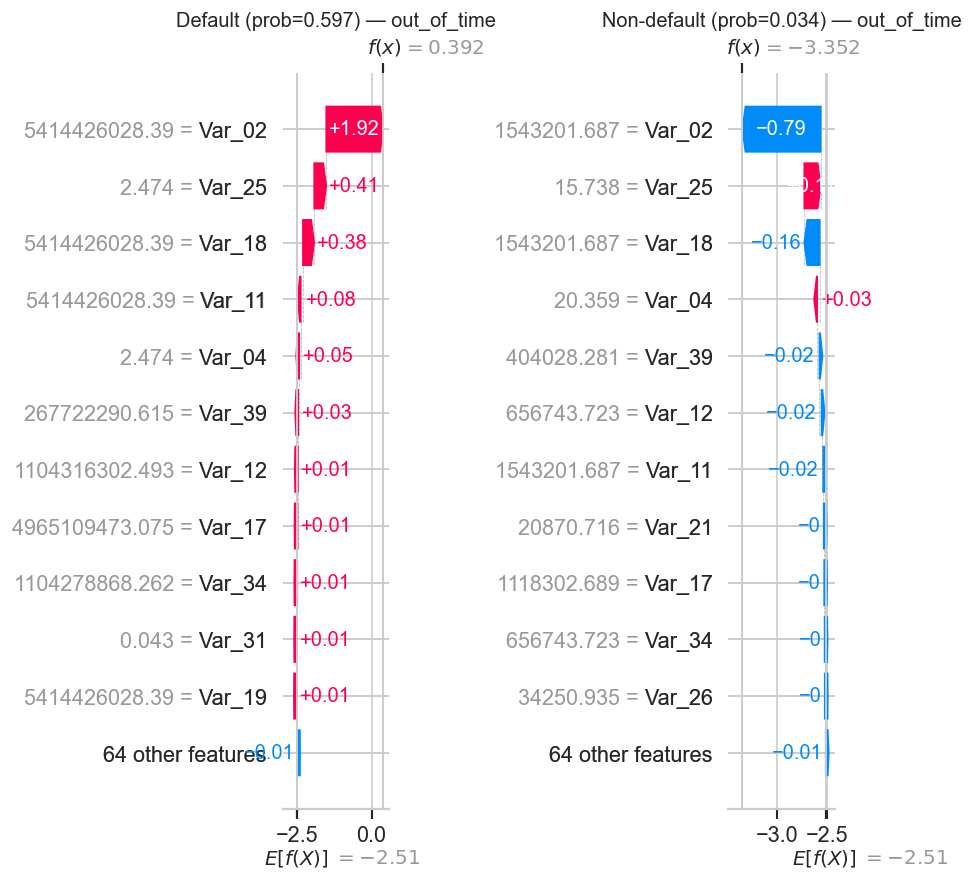

In [13]:
def plot_shap_waterfall_pair(
    shap_explanation: shap.Explanation,
    y_sample: pd.Series,
    probabilities: np.ndarray,
    split_strategy: str,
) -> None:
    """Waterfall plots for the highest-confidence default and non-default predictions.

    Provides local (loan-level) explanation — useful for demonstrating model
    interpretability to a credit officer reviewing a specific decision.

    Parameters
    ----------
    shap_explanation : shap.Explanation
        SHAP explanation for the SHAP subsample. Row i corresponds to
        y_sample.iloc[i] and probabilities[i].
    y_sample : pd.Series
        True labels, reset-indexed and aligned with shap_explanation rows.
    probabilities : np.ndarray
        Model probabilities aligned with shap_explanation rows.
    split_strategy : str
        Label for the plot title.
    """
    y_arr = y_sample.to_numpy()

    default_mask = y_arr == 1
    if default_mask.any():
        # Among true defaults, pick the one with the highest predicted probability.
        default_idx = int(np.where(default_mask)[0][np.argmax(probabilities[default_mask])])
    else:
        # Fallback: highest predicted probability regardless of true label.
        default_idx = int(np.argmax(probabilities))

    non_default_mask = y_arr == 0
    if not non_default_mask.any():
        print("No true non-defaults in the SHAP sample — skipping waterfall pair.")
        return
    non_default_idx = int(
        np.where(non_default_mask)[0][np.argmin(probabilities[non_default_mask])]
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plt.sca(axes[0])
    shap.plots.waterfall(shap_explanation[default_idx], max_display=12, show=False)
    axes[0].set_title(f"Default (prob={probabilities[default_idx]:.3f}) — {split_strategy}")

    plt.sca(axes[1])
    shap.plots.waterfall(shap_explanation[non_default_idx], max_display=12, show=False)
    axes[1].set_title(f"Non-default (prob={probabilities[non_default_idx]:.3f}) — {split_strategy}")

    plt.tight_layout()
    plt.show()


# X_shap_sample preserves the original positional index from X_valid (reset 0..N-1),
# so iloc indexing correctly aligns y_valid with the SHAP rows.
shap_probas   = tuned_model.predict_proba(X_shap_sample)[:, 1]
shap_y_sample = y_valid.iloc[X_shap_sample.index].reset_index(drop=True)

plot_shap_waterfall_pair(shap_explanation, shap_y_sample, shap_probas, SPLIT_STRATEGY)

## 7. Feature Importance Comparison: IV vs SHAP vs LightGBM Gain

Cross-method agreement strengthens interpretability claims. Discrepancies are also
informative: a feature ranked high by SHAP but low by IV captures non-linearities that
WoE binning flattened out.

In [ ]:
def build_importance_comparison(
    model: lgb.LGBMClassifier,
    shap_explanation: shap.Explanation,
    feature_columns: list[str],
    feature_name_map: dict[str, str],
    iv_summary_path: Path,
    top_n: int = 20,
) -> pd.DataFrame:
    """Rank features by three independent importance measures.

    Uses LightGBM *gain* importance (total improvement in the loss function
    across all splits on that feature), not the default *split count*, which
    tends to favour low-cardinality features.

    Parameters
    ----------
    model : lgb.LGBMClassifier
        Fitted model.
    shap_explanation : shap.Explanation
        SHAP values computed on the validation set.
    feature_columns : list[str]
        All feature names used in the model.
    feature_name_map : dict[str, str]
        Technical → readable name lookup.
    iv_summary_path : Path
        Path to woe_iv_summary.csv for IV values.
    top_n : int
        Number of features to include.

    Returns
    -------
    pd.DataFrame
        Comparison table sorted by mean |SHAP|.
    """
    # Mean |SHAP| — model-consistent, accounts for feature interactions.
    mean_abs_shap = np.abs(shap_explanation.values).mean(axis=0)
    shap_series = pd.Series(mean_abs_shap, index=shap_explanation.feature_names, name="shap")

    # LightGBM gain importance — use booster API to guarantee 'gain', not default 'split'.
    gain_values = model.booster_.feature_importance(importance_type="gain")
    lgb_series = pd.Series(gain_values, index=feature_columns, name="lgb_gain")

    comparison = pd.DataFrame({"shap": shap_series, "lgb_gain": lgb_series})

    if iv_summary_path.exists():
        iv_df = pd.read_csv(iv_summary_path)
        iv_series = iv_df.set_index("feature")["iv"]
        comparison = comparison.join(iv_series, how="left")
    else:
        comparison["iv"] = np.nan

    comparison["readable_name"] = comparison.index.map(lambda x: feature_name_map.get(x, x))
    comparison["shap_rank"] = comparison["shap"].rank(ascending=False).astype(int)
    comparison["lgb_rank"] = comparison["lgb_gain"].rank(ascending=False).astype(int)
    comparison["iv_rank"] = comparison["iv"].rank(ascending=False, na_option="bottom").astype(int)

    return comparison.sort_values("shap", ascending=False).head(top_n)


importance_df = build_importance_comparison(
    tuned_model, shap_explanation, feature_columns,
    feature_name_map, LOG_DIR / "woe_iv_summary.csv", top_n=20,
)

print("Feature Importance Comparison (top 20 by mean |SHAP|):")
display_cols = ["readable_name", "shap_rank", "iv_rank", "lgb_rank", "iv", "shap"]
importance_df[display_cols]

TypeError: NDFrame.rank() got an unexpected keyword argument 'na_position'. Did you mean 'na_option'?

In [ ]:
# Grouped bar chart: rank agreement across three methods.
top15 = importance_df.head(15)
x_pos = np.arange(len(top15))
bar_w = 0.28

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x_pos - bar_w, top15["shap_rank"], width=bar_w, label="SHAP rank", color="steelblue")
ax.bar(x_pos, top15["iv_rank"], width=bar_w, label="IV rank", color="darkorange")
ax.bar(x_pos + bar_w, top15["lgb_rank"], width=bar_w, label="LGB gain rank", color="seagreen")

labels = [feature_name_map.get(f, f)[:22] for f in top15.index]
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Rank (1 = most important)")
ax.set_title(f"Feature Ranking: SHAP vs IV vs LightGBM Gain — {SPLIT_STRATEGY}")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Test Set Evaluation & Business Interpretation

In [ ]:
test_probas = tuned_model.predict_proba(X_test)[:, 1]
test_preds = (test_probas >= optimal_threshold).astype(int)

test_metrics = evaluate_at_threshold(y_test, test_probas, optimal_threshold, "Test")

print(f"\nSplit strategy: {SPLIT_STRATEGY}")

In [ ]:
def plot_evaluation_panel(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    label: str,
) -> None:
    """Plot ROC, Precision-Recall curve, and confusion matrix side by side.

    Parameters
    ----------
    y_true : pd.Series
        True test labels.
    probabilities : np.ndarray
        Predicted probabilities.
    threshold : float
        Decision threshold applied to derive predictions.
    label : str
        Display label for titles.
    """
    predictions = (probabilities >= threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve — {label}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_true, probabilities)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, linewidth=2, label=f"PR-AUC = {pr_auc:.4f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall Curve — {label}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Confusion matrix
    cm = confusion_matrix(y_true, predictions)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
        xticklabels=["Predicted: 0", "Predicted: 1"],
        yticklabels=["Actual: 0", "Actual: 1"],
    )
    axes[2].set_title(f"Confusion Matrix — {label} (thr={threshold:.2f})")

    plt.tight_layout()
    plt.show()


plot_evaluation_panel(y_test, test_probas, optimal_threshold, f"LightGBM · {SPLIT_STRATEGY}")

In [ ]:
def generate_business_insights(
    shap_explanation: shap.Explanation,
    feature_name_map: dict[str, str],
    top_n: int = 8,
) -> pd.DataFrame:
    """Summarise the top default drivers with directional interpretation.

    Direction is inferred from the Pearson correlation between raw feature
    values and SHAP values. A positive correlation means higher feature value
    increases predicted default risk.

    Parameters
    ----------
    shap_explanation : shap.Explanation
        SHAP explanation for the SHAP sample.
    feature_name_map : dict[str, str]
        Technical → readable name lookup.
    top_n : int
        Number of top features to include.

    Returns
    -------
    pd.DataFrame
        Table with feature name, mean |SHAP|, and direction of risk.
    """
    mean_abs_shap = np.abs(shap_explanation.values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:top_n]
    rows = []
    for idx in top_idx:
        feature = shap_explanation.feature_names[idx]
        corr = float(np.corrcoef(
            shap_explanation.data[:, idx],
            shap_explanation.values[:, idx],
        )[0, 1])
        if corr > 0.1:
            direction = "↑ higher value → higher default risk"
        elif corr < -0.1:
            direction = "↓ higher value → lower default risk"
        else:
            direction = "~ non-linear / complex relationship"
        rows.append({
            "feature": feature,
            "readable_name": feature_name_map.get(feature, feature),
            "mean_abs_shap": round(float(mean_abs_shap[idx]), 5),
            "direction": direction,
            "corr(feat,shap)": round(corr, 3),
        })
    return pd.DataFrame(rows)


insights_df = generate_business_insights(shap_explanation, feature_name_map)

print("Key default drivers (LightGBM + SHAP):")
print("=" * 80)
for _, row in insights_df.iterrows():
    print(f"  • {row['readable_name']:<42s} {row['direction']}")
insights_df

In [ ]:
# Threshold scenarios — link model output to bank risk appetite.
scenarios = {}
for label, thr in [("Conservative (0.10)", 0.10),
                   (f"Optimal F1 ({optimal_threshold:.2f})", optimal_threshold),
                   ("Aggressive (0.50)", 0.50)]:
    preds = (test_probas >= thr).astype(int)
    scenarios[label] = {
        "Threshold": thr,
        "F1": round(f1_score(y_test, preds, zero_division=0), 4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "Flagged (%)": round(preds.mean() * 100, 2),
    }

print("\nThreshold scenarios (test set):")
pd.DataFrame(scenarios).T

## 9. Save Outputs

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Test set predictions — consumed by the champion comparison notebook.
predictions_df = pd.DataFrame({
    ID_COL: test_raw[ID_COL].values,
    DATE_COL: test_raw[DATE_COL].dt.strftime("%Y-%m-%d").values,
    TARGET_COL: y_test.values,
    "probability": test_probas,
    "prediction": test_preds,
})
predictions_path = RESULTS_DIR / f"lgb_test_predictions_{SPLIT_STRATEGY}.csv"
predictions_df.to_csv(predictions_path, sep=";", index=False)

# Business insights table.
insights_path = RESULTS_DIR / f"lgb_business_insights_{SPLIT_STRATEGY}.csv"
insights_df.to_csv(insights_path, index=False)

# Feature importance comparison table.
importance_path = RESULTS_DIR / f"lgb_importance_comparison_{SPLIT_STRATEGY}.csv"
importance_df.to_csv(importance_path)

# Tuning summary.
tuning_summary = {
    "split_strategy": SPLIT_STRATEGY,
    "tuning_mode": TUNING_MODE,
    "n_trials_completed": len(study.trials),
    "best_params": study.best_params,
    "best_f1_validation": round(study.best_value, 4),
    "optimal_threshold": optimal_threshold,
    "test_metrics": test_metrics,
}
tuning_path = RESULTS_DIR / f"lgb_tuning_results_{SPLIT_STRATEGY}.json"
tuning_path.write_text(json.dumps(tuning_summary, indent=2, default=str), encoding="utf-8")

print("Saved to", RESULTS_DIR)
for p in [predictions_path, insights_path, importance_path, tuning_path]:
    print(f"  {p.name}")